# Evaluating BFG on the gold set

This notebook runs every backend on the 30 figures of the gold set, scores the outputs against the hand annotations in `gold_set/annotations/`, and writes the tables and charts of the evaluation chapter to `eval_results/`.

| Question | What is measured | Table |
| --- | --- | --- |
| RQ1 | How accurately do Tesseract and TrOCR read the text printed in a figure? | 5.1 |
| RQ2 | Does adding the OCR text to the caption help the NER model find more entities? | 5.2 |
| RQ3 | Which of the three NER models (d4data, bert-base-NER, scispaCy) finds the entities best? | 5.3 |
| RQ4 | Do the generated captions say anything specific about their figure? | 5.4 |

Table 5.5 compares the entity types of the gold set with the labels the models give.

**Which figures are scored.** RQ1 to RQ3 need the hand annotations, so they use only the figures marked done in `annotate_gold_set.ipynb`, and every table reports how many figures it is based on (N). RQ4 compares generated captions with the paper captions, which exist for all 30 figures, so it uses all of them.

**Saved outputs.** Each model output is saved under `eval_results/predictions/` the first time it is computed and read back on later runs. A rerun after more figures are annotated therefore takes seconds and needs no model weights. A saved output is reused only if its run succeeded, and a NER output only if its input text has not changed. Delete `predictions/ner/` after changing a NER stage.

**Uncertainty.** Every interval is a 95% percentile interval from a figure-level bootstrap with 2,000 resamples and a fixed seed. All the statistics use the same resamples, so the differences between two runs are paired.

## 0. Setup

Imports, paths and settings. The Hugging Face libraries are put in offline mode before they are imported, so a run never tries to download anything. The model weights are read from `hf_models/` in the repository, or from the folder named by the `BFG_MODEL_CACHE` environment variable, and they are only needed for figures that have no saved output yet.

In [71]:
import json
import os
import re
import sys
import time
import warnings
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
import pandas as pd

warnings.filterwarnings('ignore')
os.environ.setdefault('HF_HUB_OFFLINE', '1')
os.environ.setdefault('TRANSFORMERS_OFFLINE', '1')
os.environ.setdefault('TRANSFORMERS_VERBOSITY', 'error')   # hides the load messages of the Hugging Face models

REPO = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'pyproject.toml').exists())
sys.path.insert(0, str(REPO / 'src'))

from bfg.config import Config
from bfg.pipeline.annotator import _tag_entity_sources, build_context_with_spans
from bfg.stages.registry import get_stage

GOLD_DIR = REPO / 'gold_set'
RESULTS_DIR = REPO / 'eval_results'
PRED_DIR = RESULTS_DIR / 'predictions'
PRED_DIR.mkdir(parents=True, exist_ok=True)

cfg = Config()
SEED, N_BOOT = 1234, 2000   # the figure-level bootstrap behind every 95% interval

## 1. Load the gold set

The list of figures comes from `gold_set/sample.json`, which the sampling notebook wrote, and each figure's annotation from `gold_set/annotations/<key>.json`. The figures marked done are the ones scored in RQ1 to RQ3.

In [72]:
sample = json.loads((GOLD_DIR / 'sample.json').read_text(encoding='utf-8'))
KEYS = [f['key'] for f in sample['figures']]

annotations = {k: json.loads((GOLD_DIR / 'annotations' / f'{k}.json').read_text(encoding='utf-8')) for k in KEYS}
paper = {k: a['paper'] for k, a in annotations.items()}
gold = {k: a['gold'] for k, a in annotations.items()}
DONE = [k for k in KEYS if gold[k]['done']]   # the figures scored in RQ1 to RQ3

print(f'{len(KEYS)} figures in the gold set, {len(DONE)} of them marked done')
if DONE:
    print('figure types:', dict(Counter(gold[k]['figure_type'] for k in DONE).most_common()))
    print('entities:', sum(len(gold[k]['entities']) for k in DONE))

30 figures in the gold set, 30 of them marked done
figure types: {'mixed': 20, 'plot': 4, 'diagram': 4, 'micrograph': 2}
entities: 455


## 2. Model inputs

Every model reads the figure image from `gold_set/images/` and the caption stored in its annotation file. The caption was taken from the article's JATS XML by the pipeline's own parser, so the NER input below is the one a normal run of the pipeline would build for the figure.

In [73]:
figure_inputs = {k: {'image_path': str(GOLD_DIR / 'images' / f'{k}.png'), 'caption': paper[k]['caption']} for k in KEYS}

missing = [k for k, v in figure_inputs.items() if not Path(v['image_path']).exists()]
assert not missing, f'images missing from gold_set/images: {missing}'
caption_words = [len(v['caption'].split()) for v in figure_inputs.values()]
print(f'{len(figure_inputs)} figures ready, captions of {min(caption_words)} to {max(caption_words)} words')

30 figures ready, captions of 16 to 462 words


## 3. Run OCR with Tesseract and TrOCR

Outputs are saved to `predictions/ocr/<backend>/<key>.json`. The helpers defined here are shared by the three cells that run models. A stage is built only when some figure has no saved output, and if the stage cannot run, the cell stops with an error instead of leaving a gap that would be scored as zero. Each record also keeps how long the run took, and the summary line gives the median time per figure. The median is used because the first figure also pays for loading the model.

In [74]:
OCR_BACKENDS = ['tesseract', 'trocr']
_stages = {}


def stage_for(backend):
    # built on the first figure without a saved output, so a fully saved rerun needs no weights and no Tesseract
    if backend not in _stages:
        stage = get_stage(backend, cfg)
        available, reason = stage.is_available()
        if not available:
            raise RuntimeError(f'{backend} is needed for figures without a saved output but cannot run: {reason}')
        _stages[backend] = stage
    return _stages[backend]


def run_saved(backend, out, payload, field, **inputs):
    """The saved record of one run, or a new run that is saved for next time.

    A record is reused only if its run succeeded on the same inputs, which are kept in the record.
    Returns the record and whether the stage was run.
    """
    saved = json.loads(out.read_text(encoding='utf-8')) if out.exists() else {}
    if saved.get('status') == 'ok' and all(saved.get(k) == v for k, v in inputs.items()):
        return saved, False
    t0 = time.time()
    r = stage_for(backend).run(payload)   # stages report a failure in the result instead of raising
    record = {**inputs, field: r.data.get(field), 'status': r.status.value, 'detail': r.detail,
              'seconds': round(time.time() - t0, 2)}
    out.parent.mkdir(parents=True, exist_ok=True)
    out.write_text(json.dumps(record, ensure_ascii=False), encoding='utf-8')
    return record, True


def report(label, runs):
    # one summary line for the (record, was_run) pairs of a backend
    runs = list(runs)
    new = sum(was_run for _, was_run in runs)
    failed = sum(record['status'] != 'ok' for record, _ in runs)
    seconds = np.median([record['seconds'] for record, _ in runs])
    print(f'{label:<44} {len(runs) - new:>2} reused, {new:>2} run, {failed} failed, median {seconds:.2f} s per figure')


ocr_preds = {}   # backend -> key -> text
for backend in OCR_BACKENDS:
    runs = {k: run_saved(backend, PRED_DIR / 'ocr' / backend / f'{k}.json', {'image_path': v['image_path']}, 'text')
            for k, v in figure_inputs.items()}
    ocr_preds[backend] = {k: record['text'] or '' for k, (record, _) in runs.items()}
    report(backend, runs.values())

tesseract                                    30 reused,  0 run, 0 failed, median 0.81 s per figure
trocr                                        30 reused,  0 run, 0 failed, median 0.39 s per figure


## 4. Run NER with three models and two contexts

Outputs are saved to `predictions/ner/<backend>/<context>/<key>.json`. The context is either the caption alone (`caption_only`) or the caption followed by the Tesseract text (`caption_plus_ocr`). Every model gets the Tesseract text, so the NER runs differ only in the model.

The input is built by the pipeline's own `build_context_with_spans`, without the abstract, because the gold entities come from the figure alone. The pipeline's tagging step then marks each entity with the part of the input it came from, caption or OCR. The same step drops entities found inside the section headers of the input, such as the word caption, which scispaCy would otherwise tag on every figure. The Hugging Face stages split long inputs into overlapping windows, so no OCR text is cut off.

In [85]:
NER_BACKENDS = ['d4data-biomedical-ner-all', 'bert-base-ner', 'scispacy']
CONTEXTS = ['caption_only', 'caption_plus_ocr']
ner_preds = defaultdict(dict)   # backend -> context -> key -> entities


def build_ner_input(key, context):
    # the pipeline's own builder, without the abstract because the gold entities come from the figure alone
    ocr_text = ocr_preds['tesseract'][key] if context == 'caption_plus_ocr' else ''
    return build_context_with_spans(abstract='', caption=figure_inputs[key]['caption'], ocr_text=ocr_text)


for backend in NER_BACKENDS:
    for ctx in CONTEXTS:
        ner_preds[backend][ctx] = {}
        runs = []
        for key in KEYS:
            text, spans = build_ner_input(key, ctx)
            record, was_run = run_saved(backend, PRED_DIR / 'ner' / backend / ctx / f'{key}.json', {'text': text},
                                        'entities', text=text)
            # the record keeps the raw stage output, and the source tagging is applied again on every run
            ner_preds[backend][ctx][key] = _tag_entity_sources(record['entities'] or [], spans)
            runs.append((record, was_run))
        report(f'{backend}, {ctx}', runs)

d4data-biomedical-ner-all, caption_only      30 reused,  0 run, 0 failed, median 0.03 s per figure
d4data-biomedical-ner-all, caption_plus_ocr  30 reused,  0 run, 0 failed, median 0.05 s per figure
bert-base-ner, caption_only                  30 reused,  0 run, 0 failed, median 0.04 s per figure
bert-base-ner, caption_plus_ocr              30 reused,  0 run, 0 failed, median 0.08 s per figure
scispacy, caption_only                       30 reused,  0 run, 0 failed, median 0.06 s per figure
scispacy, caption_plus_ocr                   30 reused,  0 run, 0 failed, median 0.08 s per figure


## 5. RQ1: OCR accuracy (Table 5.1)

Each backend's text is compared with the gold image text of the done figures. Before scoring, every run of spaces and line breaks becomes a single space, because the gold text has one printed line per line while the OCR engines break lines their own way.

The character error rate (CER) and word error rate (WER) are computed with `jiwer` and pooled over the figures, so each is the total number of edits divided by the total length of the gold text. Lower is better, and either rate can go above 1 when the output adds more characters or words than the gold text has. Both rates depend on the reading order, which is a judgement call in a busy figure, so two scores that ignore the order are reported next to them. Word recall is the share of the gold words that also appear in the output, and word precision is the share of the output words that appear in the gold text, with a repeated word counted as often as it occurs. These two also ignore capital letters, as the entity matching does.

`boot_ci` is the shared bootstrap. Every call draws the same resamples of the figures, so all the intervals in this notebook come from identical resamples.

In [86]:
import jiwer


def boot_ci(stat, n):
    # 95% percentile interval of stat(idx) over N_BOOT resamples of n figures, the same resamples on every call
    idx = np.random.default_rng(SEED).integers(0, n, size=(N_BOOT, n))
    return tuple(np.percentile([stat(i) for i in idx], [2.5, 97.5]))


def flat(text):
    # one space between words, since the gold text and the OCR engines break lines differently
    return ' '.join((text or '').split())


def edit_counts(refs, hyps, process):
    # (edits, gold length) per figure, so a pooled rate is edits.sum() / length.sum()
    rows = []
    for ref, hyp in zip(refs, hyps):
        o = process(ref, hyp)
        rows.append((o.substitutions + o.deletions + o.insertions, o.substitutions + o.deletions + o.hits))
    return np.array(rows, dtype=float)


def word_counts(refs, hyps):
    # (shared words, gold words, output words) per figure, a repeated word counted as often as it occurs
    rows = []
    for ref, hyp in zip(refs, hyps):
        r, h = Counter(ref.lower().split()), Counter(hyp.lower().split())
        rows.append((sum((r & h).values()), sum(r.values()), sum(h.values())))
    return np.array(rows, dtype=float)


ocr_keys = [k for k in DONE if flat(gold[k]['ocr_text'])]   # CER is undefined for a figure with no text
refs = [flat(gold[k]['ocr_text']) for k in ocr_keys]


def ocr_row(backend):
    hyps = [flat(ocr_preds[backend][k]) for k in ocr_keys]
    row = {'backend': backend, 'N': len(ocr_keys)}
    for name, process, corpus_score in [('CER', jiwer.process_characters, jiwer.cer), ('WER', jiwer.process_words, jiwer.wer)]:
        c = edit_counts(refs, hyps, process)
        rate = lambda idx, c=c: c[idx, 0].sum() / c[idx, 1].sum()
        row[name] = rate(np.arange(len(c)))
        assert np.isclose(row[name], corpus_score(refs, hyps))   # the pooled counts give jiwer's own corpus score
        row[f'{name}_lo'], row[f'{name}_hi'] = boot_ci(rate, len(c))
    w = word_counts(refs, hyps)
    for name, col in [('word_recall', 1), ('word_precision', 2)]:
        share = lambda idx, col=col: w[idx, 0].sum() / max(w[idx, col].sum(), 1)
        row[name] = share(np.arange(len(w)))
        row[f'{name}_lo'], row[f'{name}_hi'] = boot_ci(share, len(w))
    return row


ocr_table = pd.DataFrame([ocr_row(b) for b in OCR_BACKENDS] if ocr_keys else [])
print(f'{len(ocr_keys)} done figures with image text')
if ocr_keys:
    print(ocr_table.to_string(index=False, float_format=lambda x: f'{x:.3f}'))

30 done figures with image text
  backend  N   CER  CER_lo  CER_hi   WER  WER_lo  WER_hi  word_recall  word_recall_lo  word_recall_hi  word_precision  word_precision_lo  word_precision_hi
tesseract 30 0.658   0.625   0.691 0.893   0.835   0.952        0.367           0.298           0.446           0.425              0.351              0.502
    trocr 30 0.997   0.996   0.998 1.000   0.999   1.000        0.000           0.000           0.001           0.033              0.000              0.100


## 6. RQ2 and RQ3: entity precision, recall and F1 (Tables 5.2 and 5.3)

An entity is scored on its text alone, lower-cased and with single spaces, because the models' label sets do not match the gold types (see 6b). The gold lists each name once per figure, so each figure's predictions are also reduced to a set of unique strings. A predicted string is the exact text at the entity's position in the input, which the Hugging Face stages cut out of the input rather than rebuilding from word pieces. The counts are pooled over the done figures, giving micro-averaged precision, recall and F1.

Two matching rules are reported. Under the exact rule a prediction is correct only if it is the same string as a gold name. Under the overlap rule it also counts if one of the two contains the other and the match does not stop inside a longer word, so `hela cells` matches the gold name `hela`. The exact rule is the main result, and the overlap rule shows how much of the gap is only about where a name starts and ends. For the overlap rule, `TP` counts the gold names that were found and `FP` the predictions that match no gold name.

RQ2 is the ablation, the same model (d4data) run on the caption alone and on the caption with the OCR text. RQ3 compares the three models on the caption with the OCR text. Both come with paired differences, caption with OCR minus caption alone for RQ2, and each model minus d4data, the pipeline default, for RQ3. Two intervals can overlap while the paired difference still excludes zero, so the difference intervals are the ones to read. `OCR_only_TP` counts the correct names a model found in the OCR text but not in the caption, which is the part of the gain only the OCR text can give. It can be at most the number of gold names that appear in the gold image text but not in the caption.

In [87]:
def norm_text(s):
    return ' '.join((s or '').lower().split())


def mentions(text, name):
    # name occurs in text, ignoring case, and not as part of a longer word
    return re.search('(?<![0-9a-z])' + re.escape(name) + '(?![0-9a-z])', norm_text(text)) is not None


def pred_entity_texts(entities, sources=None):
    # unique normalised strings, optionally only those from the given parts of the input
    texts = {norm_text(e.get('word')) for e in entities or [] if sources is None or e.get('source') in sources}
    texts.discard('')
    return texts


GOLD_SETS = {k: {norm_text(e['text']) for e in gold[k]['entities']} for k in DONE}
RULES = ['exact', 'overlap']


def matches(preds, golds, rule):
    # (predictions that match a gold name, gold names matched by a prediction)
    if rule == 'exact':
        return len(preds & golds), len(preds & golds)
    hit = lambda p, g: mentions(p, g) or mentions(g, p)
    return sum(any(hit(p, g) for g in golds) for p in preds), sum(any(hit(p, g) for p in preds) for g in golds)


def counts(backend, ctx, rule='exact'):
    # per figure (matched predictions, predictions, matched gold names, gold names), in DONE order
    rows = []
    for k in DONE:
        preds, golds = pred_entity_texts(ner_preds[backend][ctx][k]), GOLD_SETS[k]
        pred_hits, gold_hits = matches(preds, golds, rule)
        rows.append((pred_hits, len(preds), gold_hits, len(golds)))
    return np.array(rows, dtype=float)


def prf(c):
    p = c[:, 0].sum() / c[:, 1].sum() if c[:, 1].sum() else 0.0
    r = c[:, 2].sum() / c[:, 3].sum() if c[:, 3].sum() else 0.0
    return p, r, (2 * p * r / (p + r) if p + r else 0.0)


def ocr_only_tp(backend, ctx):
    # gold names found in the OCR text but nowhere in the caption, under the exact rule
    total = 0
    for k in DONE:
        ents = ner_preds[backend][ctx][k]
        total += len((pred_entity_texts(ents, {'ocr'}) - pred_entity_texts(ents, {'caption'})) & GOLD_SETS[k])
    return total


def score(backend, ctx, rule):
    c = counts(backend, ctx, rule)
    row = {'backend': backend, 'context': ctx, 'match': rule, 'N': len(DONE)}
    for i, m in enumerate(['P', 'R', 'F1']):
        row[m] = prf(c)[i]
        row[f'{m}_lo'], row[f'{m}_hi'] = boot_ci(lambda idx, i=i: prf(c[idx])[i], len(c))
    row.update(TP=int(c[:, 2].sum()), FP=int((c[:, 1] - c[:, 0]).sum()), FN=int((c[:, 3] - c[:, 2]).sum()),
               OCR_only_TP=ocr_only_tp(backend, ctx), strings_per_fig=c[:, 1].mean())
    return row


def paired_delta(c_new, c_base, **labels):
    # new minus base, both scored on the same resamples of the figures
    rows = []
    for i, m in enumerate(['P', 'R', 'F1']):
        d = lambda idx, i=i: prf(c_new[idx])[i] - prf(c_base[idx])[i]
        lo, hi = boot_ci(d, len(c_new))
        rows.append({**labels, 'metric': m, 'delta': d(np.arange(len(c_new))), 'lo': lo, 'hi': hi})
    return rows


ABLATION = 'd4data-biomedical-ner-all'
rq2 = rq3 = rq2_delta = rq3_delta = pd.DataFrame()
if DONE:
    rq2 = pd.DataFrame([score(ABLATION, c, rule) for rule in RULES for c in CONTEXTS])                 # RQ2: one model, two contexts
    rq3 = pd.DataFrame([score(b, 'caption_plus_ocr', rule) for rule in RULES for b in NER_BACKENDS])   # RQ3: three models
    rq2_delta = pd.DataFrame(paired_delta(counts(ABLATION, 'caption_plus_ocr'), counts(ABLATION, 'caption_only')))
    rq3_delta = pd.DataFrame([row for b in NER_BACKENDS if b != ABLATION
                              for row in paired_delta(counts(b, 'caption_plus_ocr'), counts(ABLATION, 'caption_plus_ocr'),
                                                      backend=b)])

N_GOLD = sum(map(len, GOLD_SETS.values()))
in_caption = sum(mentions(figure_inputs[k]['caption'], e) for k in DONE for e in GOLD_SETS[k])
image_only = sum(mentions(gold[k]['ocr_text'], e) and not mentions(figure_inputs[k]['caption'], e)
                 for k in DONE for e in GOLD_SETS[k])


def _fmt(df):
    return df.to_string(index=False, float_format=lambda x: f'{x:.3f}') if len(df) else '(no figures marked done yet)'


print(f'{len(DONE)} done figures with {N_GOLD} gold names, {in_caption} of them in the caption '
      f'and {image_only} only in the image text')
for title, df in [('RQ2: d4data on the caption alone and on the caption with the OCR text', rq2),
                  ('Paired change from adding the OCR text (exact rule)', rq2_delta),
                  ('RQ3: the three models on the caption with the OCR text', rq3),
                  ('Paired change against d4data (exact rule)', rq3_delta)]:
    print()
    print(title)
    print(_fmt(df))

30 done figures with 455 gold names, 390 of them in the caption and 65 only in the image text

RQ2: d4data on the caption alone and on the caption with the OCR text
                  backend          context   match  N     P  P_lo  P_hi     R  R_lo  R_hi    F1  F1_lo  F1_hi  TP   FP  FN  OCR_only_TP  strings_per_fig
d4data-biomedical-ner-all     caption_only   exact 30 0.234 0.191 0.280 0.396 0.316 0.468 0.294  0.245  0.338 180  589 275            0           25.633
d4data-biomedical-ner-all caption_plus_ocr   exact 30 0.131 0.100 0.164 0.530 0.457 0.592 0.210  0.167  0.253 241 1602 214           50           61.433
d4data-biomedical-ner-all     caption_only overlap 30 0.469 0.402 0.528 0.633 0.536 0.720 0.539  0.473  0.591 288  408 167            0           25.633
d4data-biomedical-ner-all caption_plus_ocr overlap 30 0.270 0.227 0.319 0.767 0.692 0.829 0.400  0.347  0.453 349 1345 106           50           61.433

Paired change from adding the OCR text (exact rule)
metric  delta    

### 6b. Label schemas

Scoring on the text alone hides a second mismatch, in the labels. For the two models that give typed labels, this cell counts the labels they give on the caption with the OCR text, the labels carried by their correct strings, and the types used in the gold set. d4data was fine-tuned on MACCROBAT clinical case reports, so its label set has no type for genes, proteins or cell lines. bert-base-NER was trained on news text and knows only people, organisations, places and a miscellaneous type. scispaCy gives every entity the same label, ENTITY, so it is left out here.

In [88]:
gold_types = Counter(e['type'] for k in DONE for e in gold[k]['entities'])
schema_rows = [{'source': 'gold', 'label': t, 'share': n / sum(gold_types.values()), 'n': n} for t, n in gold_types.most_common()]

for backend in ['d4data-biomedical-ner-all', 'bert-base-ner']:
    all_labels, tp_labels = Counter(), Counter()
    for k in DONE:
        for e in ner_preds[backend]['caption_plus_ocr'][k]:
            all_labels[e.get('entity_group')] += 1
            if norm_text(e.get('word')) in GOLD_SETS[k]:
                tp_labels[e.get('entity_group')] += 1
    for source, c in [(backend, all_labels), (f'{backend} (correct strings)', tp_labels)]:
        total = sum(c.values()) or 1
        schema_rows += [{'source': source, 'label': lab, 'share': n / total, 'n': n} for lab, n in c.most_common(6)]

schema_table = pd.DataFrame(schema_rows)
print(_fmt(schema_table))

                                     source                label  share   n
                                       gold      gene_or_protein  0.382 174
                                       gold       cell_or_tissue  0.251 114
                                       gold             chemical  0.187  85
                                       gold            technique  0.097  44
                                       gold                other  0.040  18
                                       gold             organism  0.040  18
                                       gold              disease  0.004   2
                  d4data-biomedical-ner-all Diagnostic_procedure  0.425 832
                  d4data-biomedical-ner-all            Lab_value  0.377 738
                  d4data-biomedical-ner-all Detailed_description  0.098 191
                  d4data-biomedical-ner-all          Coreference  0.037  73
                  d4data-biomedical-ner-all         Sign_symptom  0.025  49
            

## 7. RQ4: generated captions (Table 5.4)

Both captioning models run on every gold image, and their outputs are saved to `predictions/vision/<backend>/<key>.json`. This part needs no hand annotation, so it uses all 30 figures. Each generated caption is compared with the figure's caption in the paper in two ways. The lexical score is the Jaccard overlap of the content words, which are the words of three or more letters that are not spaCy stop words. The semantic score is the cosine similarity of the mean word vectors of those content words, using the biomedical word vectors of scispaCy's `en_core_sci_lg` model.

A similarity means little on its own, so each figure's score against its own caption is compared with the mean score of the same generated caption against the other 29 captions, the shuffled baseline. If the generated captions say something specific about their figure, they should be closer to their own caption than to the others. `gap` is the matched score minus the shuffled one, with a bootstrap interval, and `top1` counts the figures whose own caption is the closest of all 30, where chance is 1 in 30.

In [89]:
VISION_BACKENDS = ['vit-gpt2', 'blip']
vision_preds = {}   # backend -> key -> caption

for backend in VISION_BACKENDS:
    runs = {k: run_saved(backend, PRED_DIR / 'vision' / backend / f'{k}.json', {'image_path': v['image_path']}, 'caption')
            for k, v in figure_inputs.items()}
    vision_preds[backend] = {k: record['caption'] or '' for k, (record, _) in runs.items()}
    report(backend, runs.values())

vit-gpt2                                     30 reused,  0 run, 0 failed, median 0.44 s per figure
blip                                         30 reused,  0 run, 0 failed, median 0.55 s per figure


In [90]:
import spacy

nlp = spacy.load('en_core_sci_lg')   # only the tokenizer and the static word vectors are used


def content_tokens(text):
    return [t for t in nlp.make_doc(text or '') if t.is_alpha and len(t) >= 3 and not t.is_stop]


def mean_vec(tokens):
    vs = [t.vector for t in tokens if t.has_vector]
    return np.mean(vs, axis=0) if vs else None


def cosine(u, v):
    return 0.0 if u is None or v is None else float(u @ v / (np.linalg.norm(u) * np.linalg.norm(v)))


def jaccard(a, b):
    return len(a & b) / len(a | b) if a | b else 0.0


ref_toks = [content_tokens(figure_inputs[k]['caption']) for k in KEYS]
ref_sets = [{t.lower_ for t in ts} for ts in ref_toks]
ref_vecs = [mean_vec(ts) for ts in ref_toks]
off_diag = ~np.eye(len(KEYS), dtype=bool)
print(f'word-vector coverage of caption content words: {np.mean([t.has_vector for ts in ref_toks for t in ts]):.1%}')

vision_rows = []
for backend in VISION_BACKENDS:
    hyp_toks = [content_tokens(vision_preds[backend][k]) for k in KEYS]
    sims = {
        'cosine': np.array([[cosine(mean_vec(h), r) for r in ref_vecs] for h in hyp_toks]),
        'jaccard': np.array([[jaccard({t.lower_ for t in h}, r) for r in ref_sets] for h in hyp_toks]),
    }
    for metric, S in sims.items():   # S[i, j] is the similarity of generated caption i to paper caption j
        matched = np.diag(S)
        shuffled = np.array([S[i, off_diag[i]].mean() for i in range(len(KEYS))])
        gap = matched - shuffled
        lo, hi = boot_ci(lambda idx: gap[idx].mean(), len(KEYS))
        top1 = sum(S[i, i] > S[i, off_diag[i]].max() for i in range(len(KEYS)))   # ties do not count
        vision_rows.append({'backend': backend, 'metric': metric, 'matched': matched.mean(), 'shuffled': shuffled.mean(),
                            'gap': gap.mean(), 'gap_lo': lo, 'gap_hi': hi, 'top1': int(top1), 'N': len(KEYS)})

vision_table = pd.DataFrame(vision_rows)
print(_fmt(vision_table))
print()
for k in KEYS[:6]:
    print(k, ' | '.join(f'{b}: {vision_preds[b][k]!r}' for b in VISION_BACKENDS))

word-vector coverage of caption content words: 98.8%
 backend  metric  matched  shuffled    gap  gap_lo  gap_hi  top1  N
vit-gpt2  cosine    0.389     0.383  0.006  -0.028   0.036     1 30
vit-gpt2 jaccard    0.004     0.006 -0.002  -0.004   0.002     0 30
    blip  cosine    0.367     0.368 -0.001  -0.029   0.028     2 30
    blip jaccard    0.004     0.005 -0.001  -0.004   0.005     1 30

619578v3_fig3 vit-gpt2: 'a series of photographs showing different types of objects' | blip: 'the mrna pathway of the human cell is shown in this image'
628646v3_fig2 vit-gpt2: 'a series of photos showing a series of different colored objects' | blip: 'the different stages of the mrna - mediated mrna'
638155v5_fig1 vit-gpt2: 'a series of images showing a person holding a pair of scissors' | blip: 'a diagram of the mrna pathway'
645038v6_fig5 vit-gpt2: 'a collage of photos of different types of plants' | blip: 'the mitochondrial - mediated mrna pathway of the human'
667258v2_fig11 vit-gpt2: 'a series

## 8. Per-figure results

The pooled scores above can hide large differences between figures, so this cell lists the main scores for each done figure and gives their medians for each figure type. The table is saved as `per_figure.csv`. With 30 figures spread over six types, some types have only a few figures, so the medians by type are a rough guide only.

In [91]:
def figure_row(k):
    ref = flat(gold[k]['ocr_text'])
    row = {'key': k, 'figure_type': gold[k]['figure_type'], 'gold_words': len(ref.split())}
    for backend in OCR_BACKENDS:
        hyp = flat(ocr_preds[backend][k])
        row[f'{backend}_CER'] = jiwer.cer(ref, hyp) if ref else np.nan
        row[f'{backend}_word_recall'] = word_counts([ref], [hyp])[0, 0] / len(ref.split()) if ref else np.nan
    row['gold_names'] = len(GOLD_SETS[k])
    for backend in NER_BACKENDS:   # gold names found on the caption with the OCR text, exact rule
        row[f'{backend}_found'] = len(pred_entity_texts(ner_preds[backend]['caption_plus_ocr'][k]) & GOLD_SETS[k])
    return row


per_figure = pd.DataFrame([figure_row(k) for k in DONE])
by_type = pd.DataFrame()
if DONE:
    per_figure.to_csv(RESULTS_DIR / 'per_figure.csv', index=False)
    by_type = per_figure.groupby('figure_type').median(numeric_only=True)
    by_type.insert(0, 'figures', per_figure.figure_type.value_counts())
    by_type = by_type.reset_index()
print(_fmt(by_type))

figure_type  figures  gold_words  tesseract_CER  tesseract_word_recall  trocr_CER  trocr_word_recall  gold_names  d4data-biomedical-ner-all_found  bert-base-ner_found  scispacy_found
    diagram        4      21.000          0.301                  0.679      0.981              0.000       8.500                            1.500                1.500           6.500
 micrograph        2      65.500          0.641                  0.283      1.000              0.000      17.000                            9.000                2.500          12.500
      mixed       20     122.000          0.656                  0.445      0.999              0.000      15.000                            7.500                1.500           9.000
       plot        4     161.000          0.678                  0.259      0.997              0.000      10.000                            4.500                0.500           8.000


## 9. Save the results

Each table is written as a CSV file to `eval_results/`, and `summary.md` collects them all in one file. The numbers in the report's Tables 5.1 to 5.5 are copied from these files. Until some figures are marked done, the tables for RQ1 to RQ3 are empty.

In [92]:
tables = {
    'table_5_1_ocr': ('Table 5.1: OCR against the gold image text (RQ1)', ocr_table),
    'table_5_2_ablation': ('Table 5.2: d4data on the caption alone and on the caption with the OCR text (RQ2)', rq2),
    'table_5_2_ablation_delta': ('Table 5.2b: Paired change from adding the OCR text, exact rule', rq2_delta),
    'table_5_3_ner_comparison': ('Table 5.3: The three NER models on the caption with the OCR text (RQ3)', rq3),
    'table_5_3_ner_delta': ('Table 5.3b: Paired change against d4data on the caption with the OCR text, exact rule', rq3_delta),
    'table_5_4_vision': ('Table 5.4: Generated captions against their own and the other paper captions (RQ4)', vision_table),
    'table_5_5_label_schemas': ('Table 5.5: Gold entity types and the labels of the two typed models', schema_table),
    'per_figure_type': ('Median per-figure scores by figure type', by_type),
}

lines = ['# BFG evaluation results', '',
         f'RQ1 to RQ3 use the {len(DONE)} of {len(KEYS)} gold figures marked done, with {N_GOLD} unique gold names, '
         f'{in_caption} of them in the caption and {image_only} only in the image text. RQ4 uses all {len(KEYS)} figures. '
         f'Intervals are 95% percentile intervals from {N_BOOT} figure-level bootstrap resamples (seed {SEED}).', '']
for name, (title, df) in tables.items():
    df.to_csv(RESULTS_DIR / f'{name}.csv', index=False)
    lines += [f'## {title}', '', df.to_markdown(index=False, floatfmt='.3f') if len(df) else 'No figures marked done yet.', '']
(RESULTS_DIR / 'summary.md').write_text('\n'.join(lines), encoding='utf-8')

print('Wrote:')
for p in sorted(p for p in RESULTS_DIR.glob('*') if p.is_file()):
    print(f'  {p.relative_to(REPO)}  {p.stat().st_size:,} B')

Wrote:
  eval_results/per_figure.csv  2,754 B
  eval_results/per_figure_type.csv  528 B
  eval_results/summary.md  9,558 B
  eval_results/table_5_1_ocr.csv  563 B
  eval_results/table_5_2_ablation.csv  1,121 B
  eval_results/table_5_2_ablation_delta.csv  212 B
  eval_results/table_5_3_ner_comparison.csv  1,568 B
  eval_results/table_5_3_ner_delta.csv  470 B
  eval_results/table_5_4_vision.csv  557 B
  eval_results/table_5_5_label_schemas.csv  1,566 B


## 10. Figures for the report

This cell draws the charts of the evaluation chapter from the tables above and saves them to `eval_results/figures/`. Figure 5.1 shows the OCR scores, Figure 5.2 the entity precision, recall and F1 of each model and context under both matching rules, Figure 5.3 the paired changes behind RQ2 and RQ3, and Figure 5.4 the caption gap, which is how much closer a generated caption is to its own figure's caption than to the other 29. Each dot is a point estimate and each line its 95% bootstrap interval, and the CSV files hold the exact values. The grey line in the recall panel of Figure 5.2 marks the share of the gold names that appear in the caption. Figures 5.1 to 5.3 need done figures, so they are skipped until some exist.

Blue `#2a78d6` and orange `#eb6834` stay distinguishable under the common colour-vision deficiencies and have at least 3:1 contrast on white. In Figures 5.3 and 5.4 an interval is blue when it excludes zero and grey when it does not. The charts are static PNG files because the report is a PDF.

The next cell draws Figures 3.1 and 3.2 for the design chapter, the pipeline architecture and the input the NER stage receives for a made-up figure. Figure 3.2 runs the pipeline's own `build_context_with_spans` and `_tag_entity_sources`, and its entity hits are picked by hand, not produced by a model.

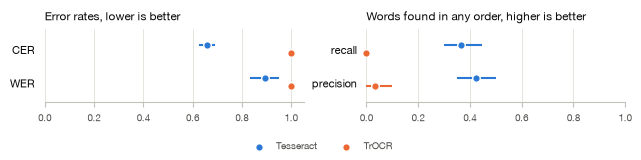

wrote eval_results/figures/fig_5_1_ocr.png


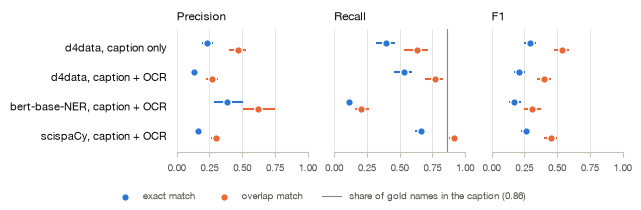

wrote eval_results/figures/fig_5_2_ner.png


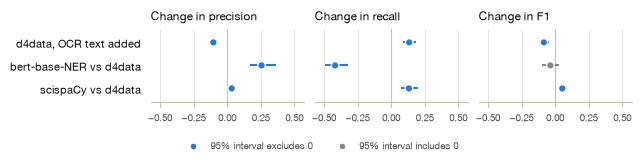

wrote eval_results/figures/fig_5_3_deltas.png


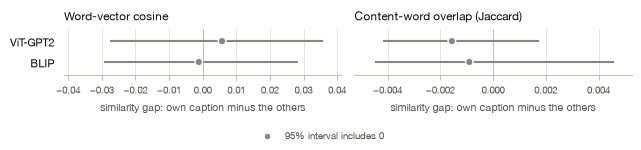

wrote eval_results/figures/fig_5_4_vision.png


In [93]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

FIG_DIR = RESULTS_DIR / 'figures'
FIG_DIR.mkdir(exist_ok=True)

BLUE, ORANGE = '#2a78d6', '#eb6834'
INK, INK_2, MUTED, GRID, AXIS = '#0b0b0b', '#52514e', '#898781', '#e1e0d9', '#c3c2b7'
plt.style.use('default')   # the IDE's dark theme would otherwise leak into the saved files
plt.rcParams.update({
    'font.family': 'sans-serif', 'font.sans-serif': ['Helvetica Neue', 'Arial', 'DejaVu Sans'], 'font.size': 8,
    'text.color': INK, 'axes.facecolor': 'white', 'axes.edgecolor': AXIS, 'axes.linewidth': 0.8,
    'axes.labelcolor': INK_2, 'axes.labelsize': 7.5, 'axes.titlesize': 8.5, 'axes.titlecolor': INK,
    'axes.titlelocation': 'left', 'axes.spines.top': False, 'axes.spines.right': False, 'axes.spines.left': False,
    'axes.grid': True, 'axes.grid.axis': 'x', 'axes.axisbelow': True, 'grid.color': GRID, 'grid.linewidth': 0.6,
    'xtick.color': AXIS, 'xtick.labelcolor': INK_2, 'xtick.labelsize': 7, 'ytick.left': False, 'ytick.labelcolor': INK,
    'legend.frameon': False, 'legend.fontsize': 7, 'legend.labelcolor': INK_2, 'figure.facecolor': 'white',
    'savefig.dpi': 300, 'savefig.bbox': 'tight', 'savefig.facecolor': 'white',
})

NER_NAMES = {'d4data-biomedical-ner-all': 'd4data', 'bert-base-ner': 'bert-base-NER', 'scispacy': 'scispaCy'}
CONTEXT_NAMES = {'caption_only': 'caption only', 'caption_plus_ocr': 'caption + OCR'}
OCR_NAMES = {'tesseract': 'Tesseract', 'trocr': 'TrOCR'}
VISION_NAMES = {'vit-gpt2': 'ViT-GPT2', 'blip': 'BLIP'}
ZERO_LABELS = {BLUE: '95% interval excludes 0', MUTED: '95% interval includes 0'}


def intervals(ax, rows, est, lo, hi, color=BLUE, dy=0.0, label=None):
    """A dot for each point estimate and a line for its 95% interval, first row on top."""
    y = np.arange(len(rows))[::-1] + dy
    # clip_on=False so that a dot sitting on 0 or 1 is drawn whole instead of cut in half by the axis edge
    ax.hlines(y, lo, hi, colors=color, linewidth=1.5, clip_on=False)
    ax.scatter(est, y, s=30, c=color, edgecolors='white', linewidths=1.0, zorder=3, label=label, clip_on=False)
    ax.set_yticks(np.arange(len(rows))[::-1], rows)
    ax.set_ylim(-0.6, len(rows) - 0.4)


def excludes_zero(lo, hi):
    return [BLUE if l > 0 or h < 0 else MUTED for l, h in zip(lo, hi)]


def zero_legend(fig, colors):
    """Legend for the excludes-zero colouring, listing only the colours in use."""
    handles = [Line2D([], [], marker='o', linestyle='', markersize=5, markerfacecolor=c, markeredgecolor='white',
                      label=label) for c, label in ZERO_LABELS.items() if c in colors]
    fig.legend(handles=handles, loc='outside lower center', ncols=2)


def symmetric_limit(values):
    # an x range centred on zero that fits every interval, and never an empty one
    return max(1.15 * np.abs(np.asarray(values, dtype=float)).max(), 0.001)


def save(fig, name):
    fig.savefig(FIG_DIR / f'{name}.png')
    plt.show()
    print('wrote', (FIG_DIR / f'{name}.png').relative_to(REPO))


def plot_ocr(table):
    """Figure 5.1: error rates and order-free word scores of the two OCR backends (RQ1)."""
    t = table.set_index('backend')
    fig, axes = plt.subplots(1, 2, figsize=(6.3, 1.5), layout='constrained')
    panels = [('Error rates, lower is better', ['CER', 'WER'], ['CER', 'WER']),
              ('Words found in any order, higher is better', ['word_recall', 'word_precision'], ['recall', 'precision'])]
    for ax, (title, metrics, names) in zip(axes, panels):
        for backend, color, dy in [('tesseract', BLUE, 0.12), ('trocr', ORANGE, -0.12)]:
            r = t.loc[backend]
            intervals(ax, names, r[metrics].astype(float), r[[f'{m}_lo' for m in metrics]].astype(float),
                      r[[f'{m}_hi' for m in metrics]].astype(float), color, dy, OCR_NAMES[backend])
        ax.set_title(title)
    axes[0].set_xlim(0, max(1.0, 1.05 * t[['CER_hi', 'WER_hi']].to_numpy().max()))
    axes[1].set_xlim(0, 1)
    fig.legend(*axes[0].get_legend_handles_labels(), loc='outside lower center', ncols=2)
    save(fig, 'fig_5_1_ocr')


def plot_ner(rq2, rq3):
    """Figure 5.2: entity precision, recall and F1 per model and context, under both matching rules (RQ2, RQ3)."""
    ner = pd.concat([rq2, rq3]).drop_duplicates(['backend', 'context', 'match'])
    fig, axes = plt.subplots(1, 3, figsize=(6.3, 2.0), sharex=True, sharey=True, layout='constrained')
    for ax, m, title in zip(axes, ['P', 'R', 'F1'], ['Precision', 'Recall', 'F1']):
        for rule, color, dy in [('exact', BLUE, 0.12), ('overlap', ORANGE, -0.12)]:
            d = ner[ner.match == rule]
            rows = [f'{NER_NAMES[b]}, {CONTEXT_NAMES[c]}' for b, c in zip(d.backend, d.context)]
            intervals(ax, rows, d[m], d[f'{m}_lo'], d[f'{m}_hi'], color, dy, f'{rule} match')
        ax.set_title(title)
        ax.set_xlim(0, 1)
        ax.set_xticks([0, 0.25, 0.5, 0.75, 1])
    # the grey line is named in the legend, since a label inside the panel would sit on top of the data
    share = in_caption / N_GOLD
    axes[1].axvline(share, color=MUTED, linewidth=0.8, zorder=1)
    handles, labels = axes[0].get_legend_handles_labels()
    handles.append(Line2D([], [], color=MUTED, linewidth=0.8))
    labels.append(f'share of gold names in the caption ({share:.2f})')
    fig.legend(handles, labels, loc='outside lower center', ncols=3)
    save(fig, 'fig_5_2_ner')


def plot_deltas(rq2_delta, rq3_delta):
    """Figure 5.3: the paired changes behind RQ2 and RQ3, exact rule."""
    deltas = pd.concat([rq2_delta.assign(comparison='d4data, OCR text added'),
                        rq3_delta.assign(comparison=rq3_delta.backend.map(NER_NAMES) + ' vs d4data')])
    comparisons = list(dict.fromkeys(deltas.comparison))
    used = set()
    fig, axes = plt.subplots(1, 3, figsize=(6.3, 1.5), sharex=True, sharey=True, layout='constrained')
    for ax, m, title in zip(axes, ['P', 'R', 'F1'], ['Change in precision', 'Change in recall', 'Change in F1']):
        d = deltas[deltas.metric == m].set_index('comparison').loc[comparisons]
        colors = excludes_zero(d.lo, d.hi)
        used.update(colors)
        ax.axvline(0, color=AXIS, linewidth=0.8, zorder=1)
        intervals(ax, comparisons, d.delta, d.lo, d.hi, colors)
        ax.set_title(title)
    lim = symmetric_limit(deltas[['lo', 'hi']])
    axes[0].set_xlim(-lim, lim)
    zero_legend(fig, used)
    save(fig, 'fig_5_3_deltas')


def plot_vision(table):
    """Figure 5.4: similarity of each generated caption to its own paper caption minus that to the others (RQ4)."""
    used = set()
    fig, axes = plt.subplots(1, 2, figsize=(6.3, 1.4), sharey=True, layout='constrained')
    for ax, metric, title in zip(axes, ['cosine', 'jaccard'], ['Word-vector cosine', 'Content-word overlap (Jaccard)']):
        v = table[table.metric == metric]
        colors = excludes_zero(v.gap_lo, v.gap_hi)
        used.update(colors)
        ax.axvline(0, color=AXIS, linewidth=0.8, zorder=1)
        intervals(ax, [VISION_NAMES[b] for b in v.backend], v.gap, v.gap_lo, v.gap_hi, colors)
        lim = symmetric_limit(v[['gap_lo', 'gap_hi']])
        ax.set_xlim(-lim, lim)
        ax.set_title(title)
        ax.set_xlabel('similarity gap: own caption minus the others')
    zero_legend(fig, used)
    save(fig, 'fig_5_4_vision')


if len(ocr_table):
    plot_ocr(ocr_table)
if DONE:
    plot_ner(rq2, rq3)
    plot_deltas(rq2_delta, rq3_delta)
else:
    print('Figures 5.1 to 5.3 are drawn once some figures are marked done.')
plot_vision(vision_table)

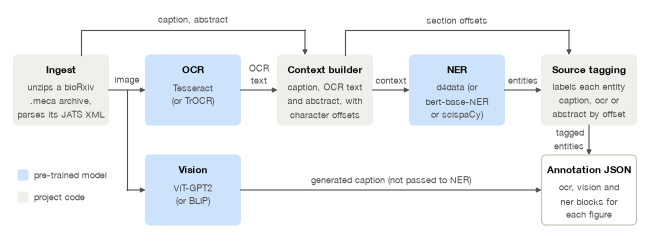

wrote eval_results/figures/fig_3_1_architecture.png


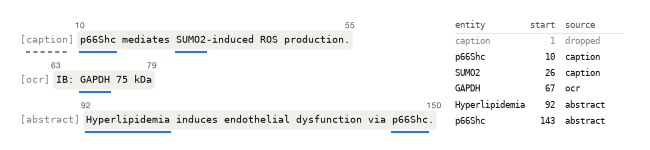

wrote eval_results/figures/fig_3_2_context.png


In [94]:
import re
from matplotlib.patches import FancyBboxPatch

MODEL_FILL, CODE_FILL = '#cde2fb', '#f0efec'
MONO = 'DejaVu Sans Mono'


def canvas(width, height):
    """A blank figure whose data units are inches, for hand-placed diagrams.

    The saved image keeps the whole canvas, so size it to the content.
    """
    fig = plt.figure(figsize=(width, height))
    ax = fig.add_axes((0, 0, 1, 1))
    ax.set(xlim=(0, width), ylim=(0, height))
    ax.axis('off')
    return fig, ax


def rounded(ax, x, y, w, h, fill, edge=None, r=0.05):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle=f'round,pad=0,rounding_size={r}',
                                facecolor=fill, edgecolor=edge or fill, linewidth=0.8))


def node(ax, x, y, title, detail, fill, w=0.95, h=0.7):
    rounded(ax, x - w / 2, y - h / 2, w, h, fill, AXIS if fill == 'white' else None)
    ax.text(x, y + h / 2 - 0.08, title, ha='center', va='top', fontsize=7.5, fontweight='bold')
    ax.text(x, y + h / 2 - 0.26, detail, ha='center', va='top', fontsize=6.5, color=INK_2, linespacing=1.3)


def link(ax, points, label=None, at=None, ha='center', va='bottom'):
    """A line through the points with an arrowhead on the last one, and an optional label at `at`."""
    xs, ys = zip(*points)
    ax.plot(xs[:-1], ys[:-1], color=INK_2, linewidth=0.8)
    ax.annotate('', xy=points[-1], xytext=points[-2],
                arrowprops=dict(arrowstyle='-|>', color=INK_2, linewidth=0.8, mutation_scale=7, shrinkA=0, shrinkB=0))
    if label:
        ax.text(*at, label, ha=ha, va=va, fontsize=6.5, color=INK_2, linespacing=1.2)


# Figure 3.1: the pipeline for one figure. Five columns, the NER path on top and the vision path below.
fig, ax = canvas(6.3, 2.25)
X = [0.51 + 1.32 * i for i in range(5)]   # column centres: 0.95 in boxes with 0.37 in gaps
TOP, BOTTOM, ARC, HALF_W, HALF_H = 1.45, 0.45, 2.05, 0.475, 0.35
node(ax, X[0], TOP, 'Ingest', 'unzips a bioRxiv\n.meca archive,\nparses its JATS XML', CODE_FILL)
node(ax, X[1], TOP, 'OCR', 'Tesseract\n(or TrOCR)', MODEL_FILL)
node(ax, X[1], BOTTOM, 'Vision', 'ViT-GPT2\n(or BLIP)', MODEL_FILL)
node(ax, X[2], TOP, 'Context builder', 'caption, OCR text\nand abstract, with\ncharacter offsets', CODE_FILL)
node(ax, X[3], TOP, 'NER', 'd4data (or\nbert-base-NER\nor scispaCy)', MODEL_FILL)
node(ax, X[4], TOP, 'Source tagging', 'labels each entity\ncaption, ocr or\nabstract by offset', CODE_FILL)
node(ax, X[4], BOTTOM, 'Annotation JSON', 'ocr, vision and\nner blocks for\neach figure', 'white')

gap_mid = [x + 0.66 for x in X[:4]]
link(ax, [(X[0] + HALF_W, TOP), (X[1] - HALF_W, TOP)], 'image', (gap_mid[0], TOP + 0.03))
link(ax, [(gap_mid[0], TOP), (gap_mid[0], BOTTOM), (X[1] - HALF_W, BOTTOM)])
link(ax, [(X[0] + 0.2, TOP + HALF_H), (X[0] + 0.2, ARC), (X[2] - 0.2, ARC), (X[2] - 0.2, TOP + HALF_H)],
     'caption, abstract', (X[1], ARC + 0.03))
link(ax, [(X[1] + HALF_W, TOP), (X[2] - HALF_W, TOP)], 'OCR\ntext', (gap_mid[1], TOP + 0.03))
link(ax, [(X[2] + HALF_W, TOP), (X[3] - HALF_W, TOP)], 'context', (gap_mid[2], TOP + 0.03))
link(ax, [(X[2] + 0.2, TOP + HALF_H), (X[2] + 0.2, ARC), (X[4] - 0.2, ARC), (X[4] - 0.2, TOP + HALF_H)],
     'section offsets', (X[3], ARC + 0.03))
link(ax, [(X[3] + HALF_W, TOP), (X[4] - HALF_W, TOP)], 'entities', (gap_mid[3], TOP + 0.03))
link(ax, [(X[4], TOP - HALF_H), (X[4], BOTTOM + HALF_H)], 'tagged\nentities', (X[4] - 0.05, (TOP + BOTTOM) / 2),
     ha='right', va='center')
link(ax, [(X[1] + HALF_W, BOTTOM), (X[4] - HALF_W, BOTTOM)], 'generated caption (not passed to NER)',
     ((X[1] + X[4]) / 2, BOTTOM + 0.03))
for i, (fill, text) in enumerate([(MODEL_FILL, 'pre-trained model'), (CODE_FILL, 'project code')]):
    rounded(ax, 0.08, 0.55 - i * 0.22, 0.1, 0.1, fill, r=0.02)
    ax.text(0.24, 0.6 - i * 0.22, text, va='center', fontsize=6.5, color=INK_2)
save(fig, 'fig_3_1_architecture')

# Figure 3.2: the context string the NER stage receives for a toy figure, and the source each entity is given.
# The offsets and tags come from the pipeline's own functions; the entity hits are illustrative, not model output.
caption = 'p66Shc mediates SUMO2-induced ROS production.'
ocr_text = 'IB: GAPDH 75 kDa'
abstract = 'Hyperlipidemia induces endothelial dysfunction via p66Shc.'
context, spans = build_context_with_spans(abstract=abstract, caption=caption, ocr_text=ocr_text)
hits = ['caption', 'p66Shc', 'SUMO2', 'GAPDH', 'Hyperlipidemia']
entities = sorted(({'word': w, 'start': m.start()} for w in hits for m in re.finditer(re.escape(w), context)),
                  key=lambda e: e['start'])
kept = {e['start']: e['source'] for e in _tag_entity_sources(entities, spans)}

fig, ax = canvas(6.3, 1.3)
probe = ax.text(0, 0, 'x' * 100, family=MONO, fontsize=7)
cw = probe.get_window_extent(fig.canvas.get_renderer()).width / fig.dpi / 100   # inches per character
probe.remove()
x0, line_start = 0.1, 0
for line, y in zip(context.split('\n\n'), [1.0, 0.6, 0.2]):
    head = line[:line.index('] ') + 2]
    span = next(s for s in spans if s.start == line_start + len(head))
    left, right = x0 + len(head) * cw, x0 + len(line) * cw
    rounded(ax, left - 0.02, y - 0.09, right - left + 0.04, 0.18, CODE_FILL, r=0.03)
    ax.text(x0, y, head, family=MONO, fontsize=7, color=MUTED, va='center')
    ax.text(left, y, line[len(head):], family=MONO, fontsize=7, va='center')
    for x, offset in [(left, span.start), (right, span.end)]:
        ax.text(x, y + 0.1, offset, fontsize=6, color=INK_2, ha='center', va='bottom')
    for e in entities:
        if line_start <= e['start'] < line_start + len(line):
            a = x0 + (e['start'] - line_start) * cw
            ax.plot([a, a + len(e['word']) * cw], [y - 0.12] * 2, linewidth=1.5,
                    color=BLUE if e['start'] in kept else MUTED, linestyle='-' if e['start'] in kept else (0, (2, 1.5)))
    line_start += len(line) + 2

tx, ty = 4.45, 1.15
ax.text(tx, ty, f'{"entity":<15}{"start":>5}  source', family=MONO, fontsize=6.5, color=INK_2, va='center')
ax.plot([tx, tx + 28 * cw], [ty - 0.08] * 2, color=GRID, linewidth=0.6)
for i, e in enumerate(entities, 1):
    source = kept.get(e['start'], 'dropped')
    ax.text(tx, ty - 0.16 * i, f'{e["word"]:<15}{e["start"]:>5}  {source}', family=MONO, fontsize=6.5,
            color=INK if e['start'] in kept else MUTED, va='center')
save(fig, 'fig_3_2_context')